# CS547-T03-TP-Figures

In [ ]:

import pandas as pd

# Define the data as a list of dictionaries
data = [
    {
        "ID": "T01", "Component": "API endpoints", "STRIDE": "Spoofing",
        "Threat Description": "Unauthenticated writes to cart/orders",
        "L(SF)": 2, "I(SF)": 4, "R(SF)": 8,
        "L(SL)": 2, "I(SL)": 4, "R(SL)": 8,
        "Mitigation": "API key enforcement on POST ✓"
    },
    {
        "ID": "T02", "Component": "API input", "STRIDE": "Tampering",
        "Threat Description": "Malicious parameters (negative qty, oversized strings)",
        "L(SF)": 2, "I(SF)": 3, "R(SF)": 6,
        "L(SL)": 2, "I(SL)": 3, "R(SL)": 6,
        "Mitigation": "Pydantic schemas (SF); manual validation (SL) ✓"
    },
    {
        "ID": "T03", "Component": "DB queries", "STRIDE": "Tampering",
        "Threat Description": "SQL/NoSQL injection",
        "L(SF)": 1, "I(SF)": 5, "R(SF)": 5,
        "L(SL)": 1, "I(SL)": 4, "R(SL)": 4,
        "Mitigation": "ORM parameterization (SF); SDK key-value API (SL) ✓"
    },
    {
        "ID": "T04", "Component": "Logging", "STRIDE": "Repudiation",
        "Threat Description": "No request tracing for forensic investigation",
        "L(SF)": 2, "I(SF)": 3, "R(SF)": 6,
        "L(SL)": 2, "I(SL)": 3, "R(SL)": 6,
        "Mitigation": "Request-ID middleware ✓; structured JSON logs ✓"
    },
    {
        "ID": "T05", "Component": "Error responses", "STRIDE": "Info Disclosure",
        "Threat Description": "Stack traces / internal details leaked to client",
        "L(SF)": 2, "I(SF)": 4, "R(SF)": 8,
        "L(SL)": 2, "I(SL)": 4, "R(SL)": 8,
        "Mitigation": "Global exception handler (SF) ✓; generic 500 (SL) ✓"
    },
    {
        "ID": "T06", "Component": "API service", "STRIDE": "DoS",
        "Threat Description": "High request volume overloads service",
        "L(SF)": 4, "I(SF)": 4, "R(SF)": 16,
        "L(SL)": 3, "I(SL)": 3, "R(SL)": 9,
        "Mitigation": "Rate limiting (SF); API Gateway throttling (SL — not yet configured)"
    },
    {
        "ID": "T07", "Component": "Server/OS", "STRIDE": "EoP",
        "Threat Description": "OS/service exploit via unpatched vulnerability",
        "L(SF)": 3, "I(SF)": 5, "R(SF)": 15,
        "L(SL)": 1, "I(SL)": 5, "R(SL)": 5,
        "Mitigation": "Manual patching (SF); provider-managed (SL) ✓"
    },
    {
        "ID": "T08", "Component": "IAM Role", "STRIDE": "EoP",
        "Threat Description": "Over-privileged Lambda role enables data exfiltration",
        "L(SF)": None, "I(SF)": None, "R(SF)": None,
        "L(SL)": 3, "I(SL)": 5, "R(SL)": 15,
        "Mitigation": "Least-privilege policy ✓ (reduced from DynamoDBCrudPolicy)"
    },
    {
        "ID": "T09", "Component": "API Gateway", "STRIDE": "Spoofing",
        "Threat Description": "Public invocation without authorizer",
        "L(SF)": None, "I(SF)": None, "R(SF)": None,
        "L(SL)": 4, "I(SL)": 4, "R(SL)": 16,
        "Mitigation": "API key in Lambda code ✓; no Gateway authorizer (gap)"
    },
    {
        "ID": "T10", "Component": "Dependencies", "STRIDE": "Tampering",
        "Threat Description": "Malicious/vulnerable dependency in supply chain",
        "L(SF)": 3, "I(SF)": 5, "R(SF)": 15,
        "L(SL)": 2, "I(SL)": 4, "R(SL)": 8,
        "Mitigation": "Pinned versions ✓; pip-audit ✓; no SBOM (gap)"
    },
    {
        "ID": "T11", "Component": "Secrets (.env)", "STRIDE": "Info Disclosure",
        "Threat Description": "Hardcoded or committed secrets",
        "L(SF)": 3, "I(SF)": 5, "R(SF)": 15,
        "L(SL)": 3, "I(SL)": 5, "R(SL)": 15,
        "Mitigation": ".gitignore ✓; but API_KEY in template.yaml plaintext (SL gap)"
    },
    {
        "ID": "T12", "Component": "GET /orders", "STRIDE": "Info Disclosure",
        "Threat Description": "All users’ orders returned (broken access control)",
        "L(SF)": 5, "I(SF)": 5, "R(SF)": 25,
        "L(SL)": 1, "I(SL)": 5, "R(SL)": 5,
        "Mitigation": "CRITICAL (SF): list_orders missing user_id filter"
    },
    {
        "ID": "T13", "Component": "Rate limiter", "STRIDE": "DoS",
        "Threat Description": "Memory exhaustion via unbounded dict growth",
        "L(SF)": 3, "I(SF)": 3, "R(SF)": 9,
        "L(SL)": None, "I(SL)": None, "R(SL)": None,
        "Mitigation": "Replace with Redis or external rate limiter"
    },
    {
        "ID": "T14", "Component": "Cost amplification", "STRIDE": "DoS",
        "Threat Description": "Denial-of-wallet via repeated Lambda invocations",
        "L(SF)": None, "I(SF)": None, "R(SF)": None,
        "L(SL)": 4, "I(SL)": 3, "R(SL)": 12,
        "Mitigation": "API Gateway usage plans + budget alarms"
    }
]

# Create the DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
print(df.to_string())



     ID           Component           STRIDE                                      Threat Description  L(SF)  I(SF)  R(SF)  L(SL)  I(SL)  R(SL)                                                            Mitigation
0   T01       API endpoints         Spoofing                   Unauthenticated writes to cart/orders    2.0    4.0    8.0    2.0    4.0    8.0                                         API key enforcement on POST ✓
1   T02           API input        Tampering  Malicious parameters (negative qty, oversized strings)    2.0    3.0    6.0    2.0    3.0    6.0                       Pydantic schemas (SF); manual validation (SL) ✓
2   T03          DB queries        Tampering                                     SQL/NoSQL injection    1.0    5.0    5.0    1.0    4.0    4.0                   ORM parameterization (SF); SDK key-value API (SL) ✓
3   T04             Logging      Repudiation           No request tracing for forensic investigation    2.0    3.0    6.0    2.0    3.0    6.0      

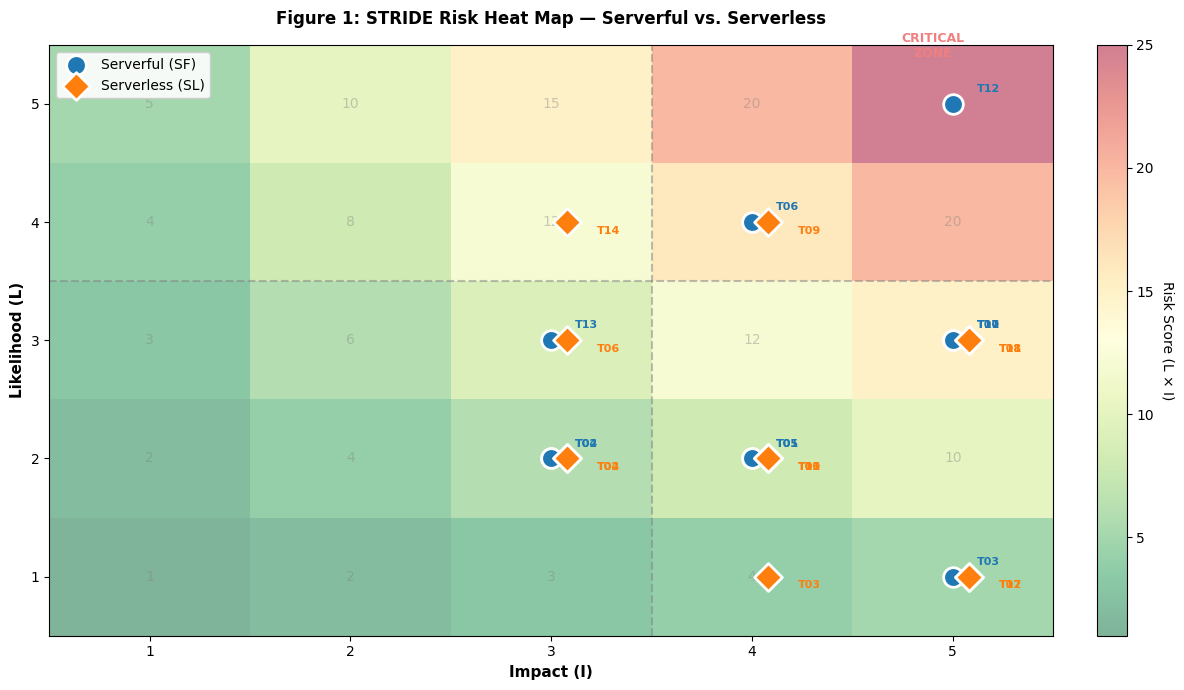

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the Data (Using the same data from the previous step)
data = [
    {"ID": "T01", "I(SF)": 4, "L(SF)": 2, "I(SL)": 4, "L(SL)": 2},
    {"ID": "T02", "I(SF)": 3, "L(SF)": 2, "I(SL)": 3, "L(SL)": 2},
    {"ID": "T03", "I(SF)": 5, "L(SF)": 1, "I(SL)": 4, "L(SL)": 1},
    {"ID": "T04", "I(SF)": 3, "L(SF)": 2, "I(SL)": 3, "L(SL)": 2},
    {"ID": "T05", "I(SF)": 4, "L(SF)": 2, "I(SL)": 4, "L(SL)": 2},
    {"ID": "T06", "I(SF)": 4, "L(SF)": 4, "I(SL)": 3, "L(SL)": 3},
    {"ID": "T07", "I(SF)": 5, "L(SF)": 3, "I(SL)": 5, "L(SL)": 1},
    {"ID": "T08", "I(SF)": None, "L(SF)": None, "I(SL)": 5, "L(SL)": 3},
    {"ID": "T09", "I(SF)": None, "L(SF)": None, "I(SL)": 4, "L(SL)": 4},
    {"ID": "T10", "I(SF)": 5, "L(SF)": 3, "I(SL)": 4, "L(SL)": 2},
    {"ID": "T11", "I(SF)": 5, "L(SF)": 3, "I(SL)": 5, "L(SL)": 3},
    {"ID": "T12", "I(SF)": 5, "L(SF)": 5, "I(SL)": 5, "L(SL)": 1},
    {"ID": "T13", "I(SF)": 3, "L(SF)": 3, "I(SL)": None, "L(SL)": None},
    {"ID": "T14", "I(SF)": None, "L(SF)": None, "I(SL)": 3, "L(SL)": 4}
]
df = pd.DataFrame(data)

# 2. Setup the Base Figure and Grid
fig, ax = plt.subplots(figsize=(12, 7))

# Create the 1-5 grid for Impact (X) and Likelihood (Y)
impact_grid = np.arange(1, 6)
likelihood_grid = np.arange(1, 6)
X, Y = np.meshgrid(impact_grid, likelihood_grid)
Z = X * Y # Risk Score = L x I

# Plot the background heatmap (Green to Red reversed)
cmap = plt.cm.RdYlGn_r
c = ax.pcolormesh(X, Y, Z, cmap=cmap, shading='nearest', alpha=0.5, vmin=1, vmax=25)

# Add faint numbers inside the grid cells
for i in range(5):
    for j in range(5):
        ax.text(impact_grid[i], likelihood_grid[j], str(impact_grid[i]*likelihood_grid[j]),
                ha='center', va='center', color='gray', alpha=0.4, fontsize=10)

# 3. Plot the Data Points (Scatter)
# Drop nulls so Matplotlib doesn't throw errors
sf_df = df.dropna(subset=['L(SF)', 'I(SF)'])
sl_df = df.dropna(subset=['L(SL)', 'I(SL)'])

# To prevent perfect overlapping when SF and SL have the exact same score,
# we add a tiny visual offset (jitter) to the Serverless X coordinates
jitter = 0.08

# Plot Serverful (SF) - Blue Circles
ax.scatter(sf_df['I(SF)'], sf_df['L(SF)'], s=200, c='#1f77b4', marker='o',
           edgecolors='white', linewidths=2, label='Serverful (SF)', zorder=5)

# Plot Serverless (SL) - Orange Diamonds (with jitter)
ax.scatter(sl_df['I(SL)'] + jitter, sl_df['L(SL)'], s=200, c='#ff7f0e', marker='D',
           edgecolors='white', linewidths=2, label='Serverless (SL)', zorder=6)

# 4. Add Annotations (Labels next to points)
for idx, row in sf_df.iterrows():
    ax.text(row['I(SF)'] + 0.12, row['L(SF)'] + 0.1, row['ID'], fontsize=8, color='#1f77b4', weight='bold')

for idx, row in sl_df.iterrows():
    ax.text(row['I(SL)'] + jitter + 0.15, row['L(SL)'] - 0.1, row['ID'], fontsize=8, color='#ff7f0e', weight='bold')

# 5. Styling and Formatting
# Add the dashed "Critical Zone" lines
ax.axhline(3.5, linestyle='--', color='gray', alpha=0.5)
ax.axvline(3.5, linestyle='--', color='gray', alpha=0.5)
ax.text(4.9, 5.4, 'CRITICAL\nZONE', color='lightcoral', fontsize=9, weight='bold', ha='center')

# Set Axis Limits & Labels
ax.set_xticks(np.arange(1, 6))
ax.set_yticks(np.arange(1, 6))
ax.set_xlabel('Impact (I)', fontweight='bold', fontsize=11)
ax.set_ylabel('Likelihood (L)', fontweight='bold', fontsize=11)
ax.set_title('Figure 1: STRIDE Risk Heat Map — Serverful vs. Serverless', fontweight='bold', pad=15)

# Add Legend and Colorbar
ax.legend(loc='upper left', framealpha=0.9)
cbar = fig.colorbar(c, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Risk Score (L × I)', rotation=270, labelpad=15)

# Tidy layout and show
plt.tight_layout()
plt.show()

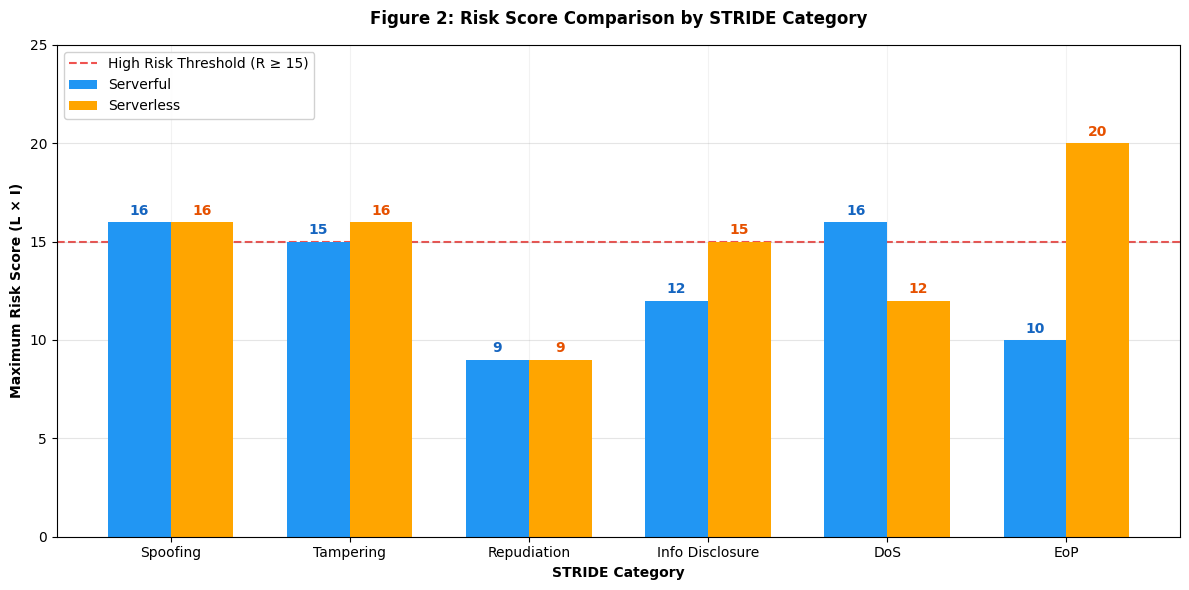

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the Data (Extracted directly from the image)
categories = ['Spoofing', 'Tampering', 'Repudiation', 'Info Disclosure', 'DoS', 'EoP']
serverful_scores = [16, 15, 9, 12, 16, 10]
serverless_scores = [16, 16, 9, 15, 12, 20]

# 2. Set up the Bar Chart Spacing
x = np.arange(len(categories))  # the label locations on the x-axis
width = 0.35  # the width of each individual bar

# 3. Create the Figure and Axes
fig, ax = plt.subplots(figsize=(12, 6))

# 4. Plot the Grouped Bars
# Subtracting/adding width/2 shifts the bars left and right so they sit side-by-side
rects1 = ax.bar(x - width/2, serverful_scores, width, label='Serverful', color='#2196F3')
rects2 = ax.bar(x + width/2, serverless_scores, width, label='Serverless', color='#FFA500')

# 5. Add the High Risk Threshold Line
ax.axhline(y=15, color='#EF5350', linestyle='--', linewidth=1.5, zorder=0, label='High Risk Threshold (R ≥ 15)')

# 6. Customize the Axes, Titles, and Limits
ax.set_ylabel('Maximum Risk Score (L × I)', fontweight='bold')
ax.set_xlabel('STRIDE Category', fontweight='bold')
ax.set_title('Figure 2: Risk Score Comparison by STRIDE Category', fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 25) # Risk scores cap at 25

# 7. Add Gridlines and Legend
ax.yaxis.grid(True, color='gray', alpha=0.2) # Faint horizontal grid lines
ax.xaxis.grid(True, color='gray', alpha=0.1) # Faint vertical grid lines
ax.set_axisbelow(True) # Ensures grid lines render behind the bars, not on top of them
ax.legend(loc='upper left', framealpha=0.9)

# 8. Attach Data Labels (The numbers floating above the bars)
ax.bar_label(rects1, padding=3, color='#1565C0', fontweight='bold')
ax.bar_label(rects2, padding=3, color='#E65100', fontweight='bold')

# 9. Tidy the layout and render
plt.tight_layout()
plt.show()

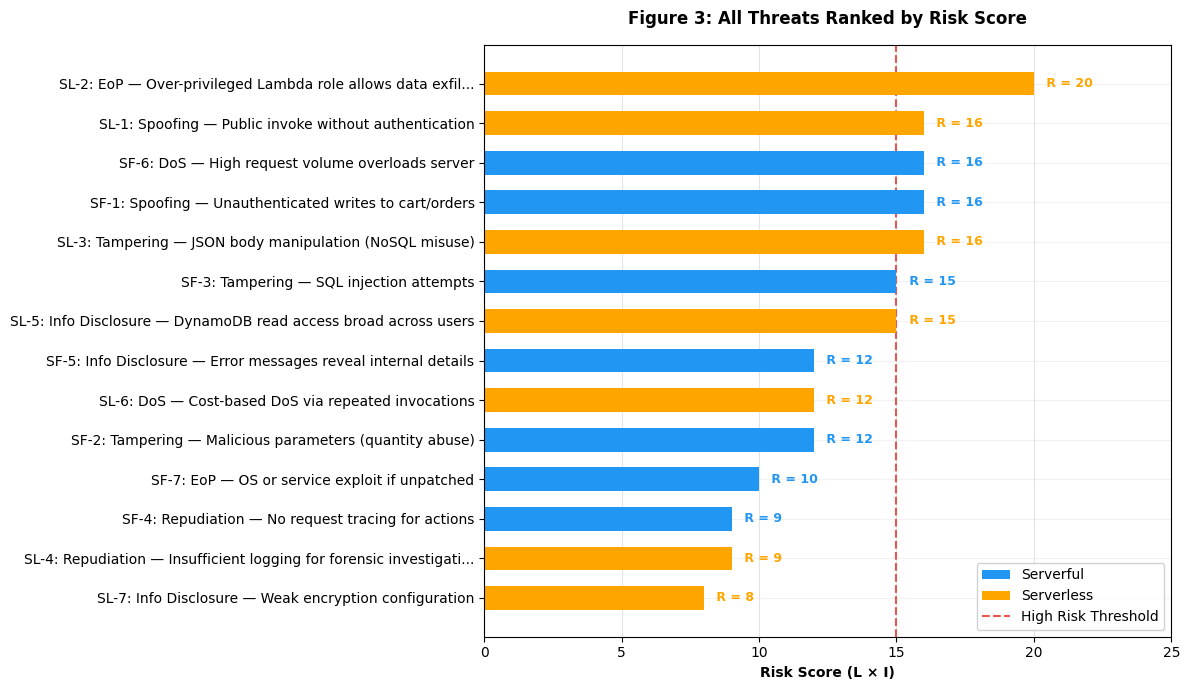

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Set the font family for the plot
plt.rcParams['font.family'] = 'DejaVu Sans'

# 1. Define the Data
# Storing as a list of dictionaries makes it easy to tie the label, score, and architecture together
data = [
    {"Label": "SL-2: EoP — Over-privileged Lambda role allows data exfil...", "Score": 20, "Type": "Serverless"},
    {"Label": "SL-3: Tampering — JSON body manipulation (NoSQL misuse)", "Score": 16, "Type": "Serverless"},
    {"Label": "SF-6: DoS — High request volume overloads server", "Score": 16, "Type": "Serverful"},
    {"Label": "SF-1: Spoofing — Unauthenticated writes to cart/orders", "Score": 16, "Type": "Serverful"},
    {"Label": "SL-1: Spoofing — Public invoke without authentication", "Score": 16, "Type": "Serverless"},
    {"Label": "SL-5: Info Disclosure — DynamoDB read access broad across users", "Score": 15, "Type": "Serverless"},
    {"Label": "SF-3: Tampering — SQL injection attempts", "Score": 15, "Type": "Serverful"},
    {"Label": "SF-2: Tampering — Malicious parameters (quantity abuse)", "Score": 12, "Type": "Serverful"},
    {"Label": "SL-6: DoS — Cost-based DoS via repeated invocations", "Score": 12, "Type": "Serverless"},
    {"Label": "SF-5: Info Disclosure — Error messages reveal internal details", "Score": 12, "Type": "Serverful"},
    {"Label": "SF-7: EoP — OS or service exploit if unpatched", "Score": 10, "Type": "Serverful"},
    {"Label": "SL-4: Repudiation — Insufficient logging for forensic investigati...", "Score": 9, "Type": "Serverless"},
    {"Label": "SF-4: Repudiation — No request tracing for actions", "Score": 9, "Type": "Serverful"},
    {"Label": "SL-7: Info Disclosure — Weak encryption configuration", "Score": 8, "Type": "Serverless"}
]

# Convert to a Pandas DataFrame for easy sorting
df = pd.DataFrame(data)

# Sort ascending because Matplotlib draws horizontal bars from bottom to top
df = df.sort_values(by="Score", ascending=True).reset_index(drop=True)

# Map the architectures to their respective colors
colors = {'Serverful': '#2196F3', 'Serverless': '#FFA500'}
bar_colors = [colors[t] for t in df['Type']]

# 2. Create the Figure and Axes
fig, ax = plt.subplots(figsize=(12, 7))

# 3. Plot the Horizontal Bars
bars = ax.barh(df['Label'], df['Score'], color=bar_colors, height=0.6)

# 4. Add the High Risk Threshold Line (Vertical this time)
ax.axvline(x=15, color='#EF5350', linestyle='--', linewidth=1.5, zorder=0, label='High Risk Threshold')

# 5. Customize the Axes, Titles, and Limits
ax.set_xlabel('Risk Score (L × I)', fontweight='bold')
ax.set_title('Figure 3: All Threats Ranked by Risk Score', fontweight='bold', pad=15)
ax.set_xlim(0, 25) # Give the bars some room to breathe on the right side

# 6. Add Gridlines and Custom Legend
ax.xaxis.grid(True, color='gray', alpha=0.2)
ax.yaxis.grid(True, color='gray', alpha=0.1)
ax.set_axisbelow(True)

# Create custom legend handles so Serverful/Serverless show up correctly
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2196F3', label='Serverful'),
    Patch(facecolor='#FFA500', label='Serverless'),
    plt.Line2D([0], [0], color='#EF5350', lw=1.5, linestyle='--', label='High Risk Threshold')
]
ax.legend(handles=legend_elements, loc='lower right', framealpha=0.9)

# 7. Attach Data Labels (The "R = X" text next to the bars)
for i, (bar, score, arch) in enumerate(zip(bars, df['Score'], df['Type'])):
    # Match the text color to the bar color for visual consistency
    text_color = colors[arch]
    ax.text(score + 0.3, bar.get_y() + bar.get_height()/2, f' R = {score}',
            va='center', color=text_color, fontweight='bold', fontsize=9)

# 8. Tidy the layout and render
plt.tight_layout()
plt.show()

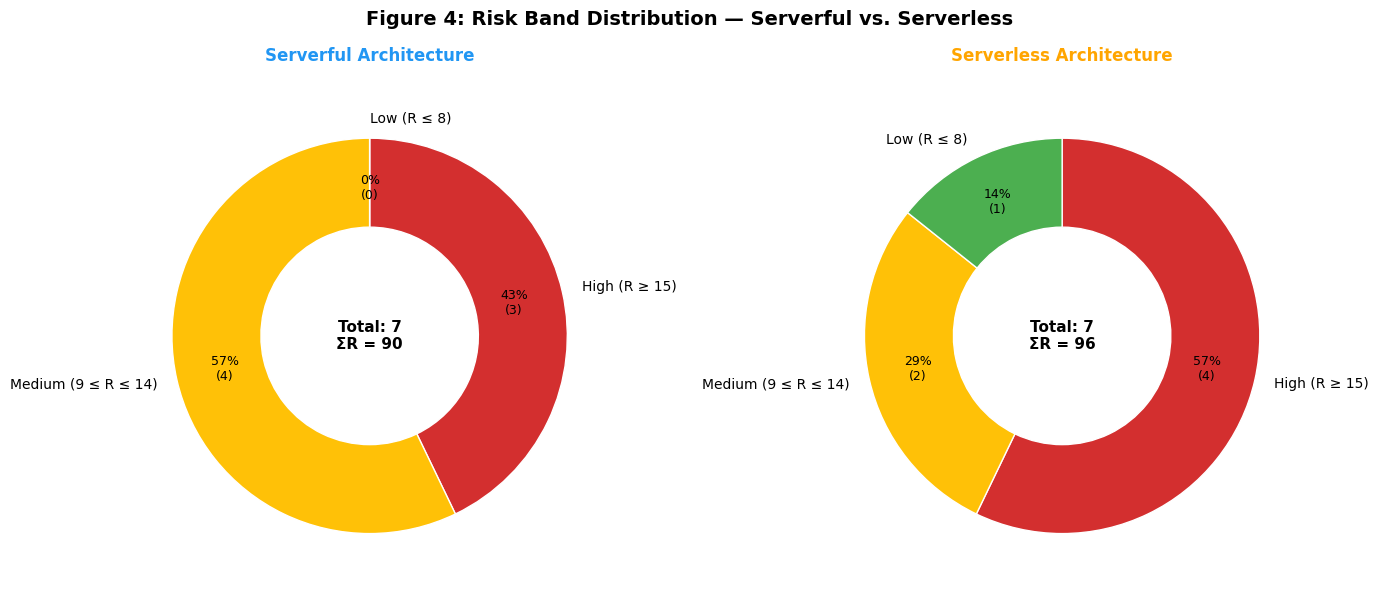

In [ ]:
import matplotlib.pyplot as plt

# Set the font family
plt.rcParams['font.family'] = 'DejaVu Sans'

# 1. Define the Data
labels = ['High (R ≥ 15)', 'Medium (9 ≤ R ≤ 14)', 'Low (R ≤ 8)']
colors = ['#D32F2F', '#FFC107', '#4CAF50'] # Red, Yellow, Green

# The data counts [High, Medium, Low]
sf_counts = [3, 4, 0]
sl_counts = [4, 2, 1]

# 2. Create the Figure and Axes (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 4: Risk Band Distribution — Serverful vs. Serverless', fontweight='bold', fontsize=14)

# Custom function to format the labels inside the donut slices
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        # Explicitly handle the 0% case so the text still renders exactly like the image
        if pct == 0:
            return "0%\n(0)"
        return f'{pct:.0f}%\n({val})'
    return my_autopct

# 3. Plot Serverful Architecture (Left)
# width=0.45 is what carves out the center to make it a donut rather than a full pie
wedges1, texts1, autotexts1 = ax1.pie(
    sf_counts, labels=labels, colors=colors, startangle=90, counterclock=False,
    wedgeprops=dict(width=0.45, edgecolor='w'), autopct=make_autopct(sf_counts), pctdistance=0.75
)
ax1.set_title('Serverful Architecture', color='#2196F3', fontweight='bold', pad=20)
ax1.text(0, 0, 'Total: 7\nΣR = 90', ha='center', va='center', fontweight='bold', fontsize=11)

# 4. Plot Serverless Architecture (Right)
wedges2, texts2, autotexts2 = ax2.pie(
    sl_counts, labels=labels, colors=colors, startangle=90, counterclock=False,
    wedgeprops=dict(width=0.45, edgecolor='w'), autopct=make_autopct(sl_counts), pctdistance=0.75
)
ax2.set_title('Serverless Architecture', color='#FFA500', fontweight='bold', pad=20)
ax2.text(0, 0, 'Total: 7\nΣR = 96', ha='center', va='center', fontweight='bold', fontsize=11)

# 5. Styling Tweaks (Adjusting text sizes and colors inside the slices)
for autotext in autotexts1 + autotexts2:
    autotext.set_color('black')
    autotext.set_fontsize(9)

for text in texts1 + texts2:
    text.set_fontsize(10)

# 6. Tidy layout and render
plt.tight_layout()
plt.show()

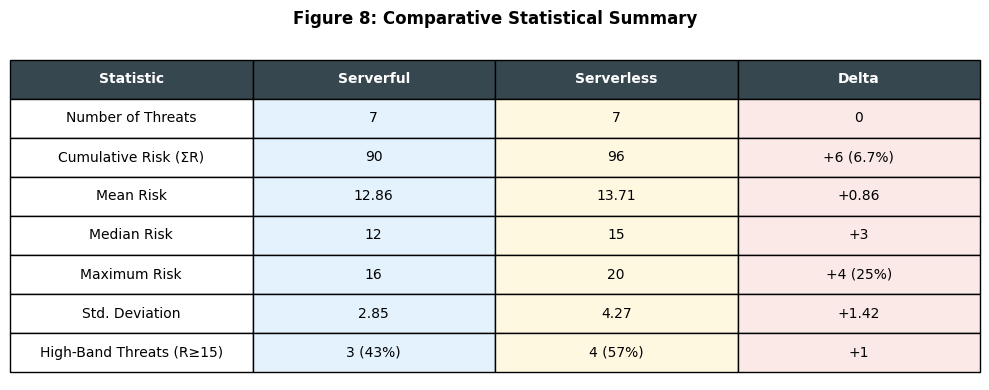

In [ ]:
import matplotlib.pyplot as plt

# 1. Set the font family to match previous figures
plt.rcParams['font.family'] = 'DejaVu Sans'

# 2. Define the Data and Headers
columns = ["Statistic", "Serverful", "Serverless", "Delta"]
data = [
    ["Number of Threats", "7", "7", "0"],
    ["Cumulative Risk (ΣR)", "90", "96", "+6 (6.7%)"],
    ["Mean Risk", "12.86", "13.71", "+0.86"],
    ["Median Risk", "12", "15", "+3"],
    ["Maximum Risk", "16", "20", "+4 (25%)"],
    ["Std. Deviation", "2.85", "4.27", "+1.42"],
    ["High-Band Threats (R≥15)", "3 (43%)", "4 (57%)", "+1"]
]

# 3. Create the Figure and Axes
fig, ax = plt.subplots(figsize=(10, 4))

# Turn off the standard x and y axes since this is just a table
ax.axis('off')
ax.axis('tight')

# 4. Create the Table
table = ax.table(cellText=data, colLabels=columns, loc='center', cellLoc='center')

# 5. Styling the Table
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2) # Scales the width and row height to give the text breathing room

# Define the precise hex colors matching your image
color_header = '#37474F'      # Dark slate grey
color_serverful = '#E3F2FD'   # Light blue
color_serverless = '#FFF8E1'  # Light yellow/orange
color_delta = '#FBE9E7'       # Light pink/red

# Loop through every cell in the table to apply specific styling
for (row, col), cell in table.get_celld().items():
    # Style the Header Row
    if row == 0:
        cell.set_facecolor(color_header)
        cell.set_text_props(color='white', weight='bold')
    # Style the Data Rows
    else:
        if col == 1:
            cell.set_facecolor(color_serverful)
        elif col == 2:
            cell.set_facecolor(color_serverless)
        elif col == 3:
            cell.set_facecolor(color_delta)

# 6. Add Title and Render
plt.title('Figure 8: Comparative Statistical Summary', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

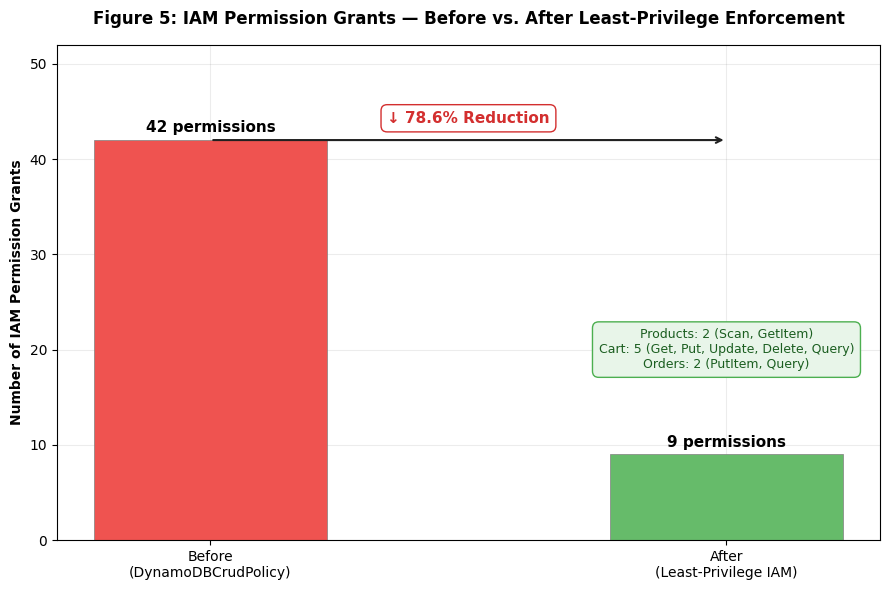

In [ ]:
import matplotlib.pyplot as plt

# 1. Set the font family to maintain consistency with your other figures
plt.rcParams['font.family'] = 'DejaVu Sans'

# 2. Create the Figure and Axes
fig, ax = plt.subplots(figsize=(9, 6))

# 3. Define the Data
labels = ['Before\n(DynamoDBCrudPolicy)', 'After\n(Least-Privilege IAM)']
values = [42, 9]

# Using standard Red and Green hex codes to match the image
colors = ['#EF5350', '#66BB6A']

# 4. Plot the Bars
# width=0.45 makes the bars a bit thinner so the text boxes have room to breathe
bars = ax.bar(labels, values, color=colors, width=0.45, edgecolor='gray', linewidth=0.5)

# 5. Add the Bar Height Labels (42 and 9)
ax.text(0, 42.5, '42 permissions', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.text(1, 9.5, '9 permissions', ha='center', va='bottom', fontweight='bold', fontsize=11)

# 6. Draw the Arrow connecting the bars
# xy is the arrow tip, xytext is the arrow tail.
ax.annotate('', xy=(1.0, 42), xytext=(0.0, 42),
            arrowprops=dict(arrowstyle='->', color='#212121', lw=1.5))

# 7. Add the "Reduction" floating box above the arrow
ax.text(0.5, 43.5, '↓ 78.6% Reduction', ha='center', va='bottom',
        color='#D32F2F', fontweight='bold', fontsize=11,
        bbox=dict(facecolor='white', edgecolor='#D32F2F', boxstyle='round,pad=0.4'))

# 8. Add the green "Details" floating box next to the After bar
details_text = "Products: 2 (Scan, GetItem)\nCart: 5 (Get, Put, Update, Delete, Query)\nOrders: 2 (PutItem, Query)"
ax.text(1, 20, details_text, ha='center', va='center', color='#1B5E20', fontsize=9,
        bbox=dict(facecolor='#E8F5E9', edgecolor='#4CAF50', boxstyle='round,pad=0.5'))

# 9. Customize Axes, Limits, and Titles
ax.set_ylim(0, 52) # Give plenty of headspace for the arrows and text
ax.set_ylabel('Number of IAM Permission Grants', fontweight='bold')
ax.set_title('Figure 5: IAM Permission Grants — Before vs. After Least-Privilege Enforcement', fontweight='bold', pad=15)

# 10. Add Gridlines
ax.grid(True, color='gray', alpha=0.15)
ax.set_axisbelow(True) # Ensure the grid stays behind the bars

# 11. Tidy layout and render
plt.tight_layout()
plt.show()

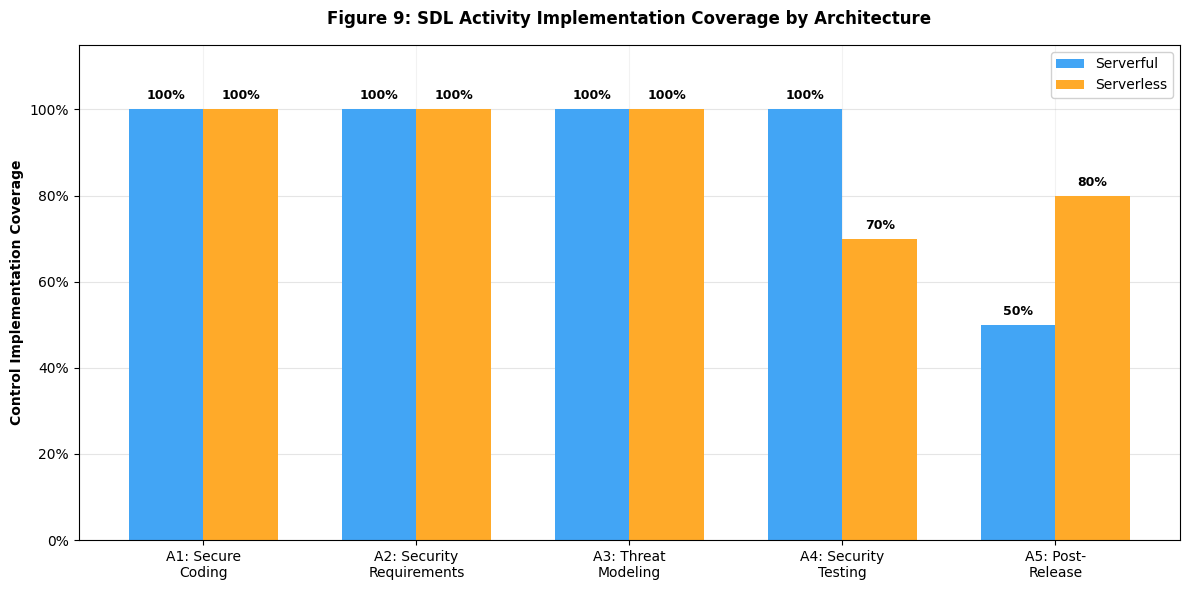

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter

# 1. Set the exact font family to maintain consistency
plt.rcParams['font.family'] = 'DejaVu Sans'

# 2. Define the Data
# Using \n to force the labels to break onto two lines exactly like the image
categories = ['A1: Secure\nCoding', 'A2: Security\nRequirements', 'A3: Threat\nModeling',
              'A4: Security\nTesting', 'A5: Post-\nRelease']

serverful_coverage = [100, 100, 100, 100, 50]
serverless_coverage = [100, 100, 100, 70, 80]

# 3. Set up the Bar Chart Spacing
x = np.arange(len(categories))
width = 0.35

# 4. Create the Figure and Axes
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the Grouped Bars (shifting x left and right to sit side-by-side)
rects1 = ax.bar(x - width/2, serverful_coverage, width, label='Serverful', color='#42A5F5')
rects2 = ax.bar(x + width/2, serverless_coverage, width, label='Serverless', color='#FFAA29')

# 5. Customize the Axes, Titles, and Limits
ax.set_ylabel('Control Implementation Coverage', fontweight='bold')
ax.set_title('Figure 9: SDL Activity Implementation Coverage by Architecture', fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(categories)

# Give the chart a ceiling higher than 100 so the floating text labels aren't cut off
ax.set_ylim(0, 115)
ax.set_yticks(np.arange(0, 120, 20))

# Convert the Y-axis numbers to percentages (0%, 20%, 40%...)
ax.yaxis.set_major_formatter(PercentFormatter())

# 6. Add Gridlines and Legend
ax.yaxis.grid(True, color='gray', alpha=0.2)
ax.xaxis.grid(True, color='gray', alpha=0.1)
ax.set_axisbelow(True)
ax.legend(loc='upper right', framealpha=0.9)

# 7. Attach Data Labels (The floating percentages on top of the bars)
def add_percentage_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # Offset 5 points vertically
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=9)

add_percentage_labels(rects1)
add_percentage_labels(rects2)

# 8. Tidy layout and render
plt.tight_layout()
plt.show()